## EDA and Encoding Data

In [26]:
# Importing required librares fro eda and encoding

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import warnings
warnings.filterwarnings("ignore")

In [12]:
# reading the data set

df = pd.read_csv('cleaned_data.csv')
pd.set_option('display.max_columns', None)
df.head()

,fuel_type,body_type,kilometers_driven,transmission,owner_no,manufacturer,model,model_year,central_variant_id,variant_name,price,registration_year,insurance,rto,top_features,comfort_features,interior_features,exterior_features,safety_features,entertainment_features,engine,max_power,torque,wheel_size,seats,color,engine_type,no_of_cylinders,values_per_cylinder,fuel_suppy_system,turbo_charger,length,width,height,wheel_base,kerb_weight,gear_box,drive_type,steering_type,front_brake_type,rear_brake_type,tyre_type,alloy_wheel_size,no_of_doors,cargo_volumn,city
0,petrol,suv,20000.0,automatic,1,kia,sonet,2022,8654,turbo dct anniversary edition,11.50,2022.0,third party,tn02,power steering power windows front air conditi...,power steering power windows front power windo...,air conditioner heater adjustable steering dig...,adjustable head lights fog lights front power ...,anti lock braking system brake assist centeral...,radio speakers front speakers rear integrated2...,998.0,118.36,172.00,16.000000,5.0,black,smartstream g1.0 t - gdi,3.0,4.0,gdi,yes,3995.0,1790.0,1642.0,2500.0,1465.0,7.0,fwd,electric,disc,drum,tubeless radial,16.000000,5.0,392.0,chennai
1,petrol,minivans,20687.0,manual,1,maruti,eeco,2015,4025,7 seater standard bsiv,4.15,2015.0,comprehensive,tn04,low fuel warning light accessory power outlet ...,low fuel warning light accessory power outlet ...,heater digital odometer electronic multi tripm...,adjustable head lights manually adjustable ext...,anti lock braking system child safety locks dr...,NaN,1196.0,73.00,101.00,15.751988,7.0,grey,in-line engine,4.0,4.0,mpfi,no,3675.0,1475.0,1800.0,2350.0,943.0,5.0,rwd,manual,ventilated disc,drum,tubeless,15.751988,5.0,540.0,chennai
2,petrol,suv,30000.0,manual,1,nissan,magnite,2021,8135,turbo xv premium bsvi,7.50,2021.0,third party,tn22,power steering power windows front air conditi...,power steering power windows front power windo...,air conditioner heater adjustable steering dig...,adjustable head lights fog lights front power ...,anti lock braking system brake assist centeral...,radio speakers front speakers rear integrated2...,999.0,98.63,160.00,16.000000,5.0,others,hra0 1.0 turbo petrol,3.0,4.0,mpfi,yes,3994.0,1758.0,1572.0,2500.0,1014.0,5.0,unknown,electric,disc,drum,tubeless radial,16.000000,5.0,336.0,chennai
3,petrol,hatchback,59247.0,manual,1,hyundai,i10,2015,1579,sportz 1.1l,3.98,2015.0,comprehensive,tn11,power steering power windows front air conditi...,power steering power windows front power windo...,air conditioner heater adjustable steering dig...,adjustable head lights fog lights front manual...,centeral locking power door locks child safety...,cd player radio speakers front speakers rear i...,1086.0,68.05,99.04,15.751988,5.0,silver,irde2 engine,4.0,3.0,mpfi,no,3585.0,1595.0,1550.0,2380.0,860.0,5.0,fwd,power,ventilated disc,drum,tubeless,15.751988,5.0,225.0,chennai
4,petrol,hatchback,50000.0,manual,1,honda,jazz,2015,1341,1.2 vx i vtec,5.50,2015.0,third party,ka03,power steering power windows front air conditi...,power steering power windows front power windo...,air conditioner heater adjustable steering dig...,adjustable head lights fog lights front power ...,anti lock braking system centeral locking powe...,cd player dvd player radio speakers front spea...,1199.0,88.70,110.00,15.000000,5.0,others,i-vtec petrol engine,4.0,4.0,pgm-fi,no,3955.0,1694.0,1544.0,2530.0,1042.0,5.0,fwd,power,disc,drum,tubeless radial,15.000000,5.0,354.0,chennai


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8259 entries, 0 to 8258
Data columns (total 46 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   fuel_type               8259 non-null   object 
 1   body_type               8259 non-null   object 
 2   kilometers_driven       8259 non-null   float64
 3   transmission            8259 non-null   object 
 4   owner_no                8259 non-null   int64  
 5   manufacturer            8259 non-null   object 
 6   model                   8259 non-null   object 
 7   model_year              8259 non-null   int64  
 8   central_variant_id      8259 non-null   int64  
 9   variant_name            8259 non-null   object 
 10  price                   8259 non-null   float64
 11  registration_year       8259 non-null   float64
 12  insurance               8259 non-null   object 
 13  rto                     8253 non-null   object 
 14  top_features            8206 non-null   

In [14]:
# checking null values 

df.isna().sum()

fuel_type                    0
body_type                    0
kilometers_driven            0
transmission                 0
owner_no                     0
manufacturer                 0
model                        0
model_year                   0
central_variant_id           0
variant_name                 0
price                        0
registration_year            0
insurance                    0
rto                          6
top_features                53
comfort_features            55
interior_features           63
exterior_features           67
safety_features             76
entertainment_features    1020
engine                       0
max_power                    0
torque                       0
wheel_size                   0
seats                        0
color                        0
engine_type                  0
no_of_cylinders              0
values_per_cylinder          0
fuel_suppy_system            0
turbo_charger                0
length                       0
width   

In [15]:
# checking categorical columns 

categorical_cols = df.select_dtypes(include=['object']).columns
categorical_cols

Index(['fuel_type', 'body_type', 'transmission', 'manufacturer', 'model',
       'variant_name', 'insurance', 'rto', 'top_features', 'comfort_features',
       'interior_features', 'exterior_features', 'safety_features',
       'entertainment_features', 'color', 'engine_type', 'fuel_suppy_system',
       'turbo_charger', 'drive_type', 'steering_type', 'front_brake_type',
       'rear_brake_type', 'tyre_type', 'city'],
      dtype='object')

In [16]:
#no of unique values in categorical columns

unique_values_counts = df[categorical_cols].nunique()
print(unique_values_counts)

fuel_type                    5
body_type                   11
transmission                 2
manufacturer                32
model                      310
variant_name              2088
insurance                    6
rto                        443
top_features               255
comfort_features          1420
interior_features          414
exterior_features         1326
safety_features           1487
entertainment_features     273
color                      133
engine_type                485
fuel_suppy_system           40
turbo_charger                5
drive_type                  10
steering_type                6
front_brake_type            11
rear_brake_type             14
tyre_type                    5
city                         6
dtype: int64


In [17]:
# model and color has more unique values rather than encoding it, we can just drop this colums 
# drive_type, steering_type, front_brake_type, rear_brake_type are indeed add unnecessary in price prediction. 
# Encoding these features could significantly increase the dimensionality of the dataset (number of columns) without necessarily improving the model's accuracy.

In [18]:
# dropping categorical columns with more unique values and which are difficult to encode and which might reduce model effficeincy 

df = df.drop(['top_features', 'comfort_features', 'interior_features', 'exterior_features', 'safety_features', 
                      'entertainment_features','variant_name','rto','engine_type','central_variant_id','fuel_suppy_system'], axis=1)

In [19]:
df = df.drop(['model', 'color','drive_type','steering_type', 'front_brake_type', 'rear_brake_type'], axis=1)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8259 entries, 0 to 8258
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   fuel_type            8259 non-null   object 
 1   body_type            8259 non-null   object 
 2   kilometers_driven    8259 non-null   float64
 3   transmission         8259 non-null   object 
 4   owner_no             8259 non-null   int64  
 5   manufacturer         8259 non-null   object 
 6   model_year           8259 non-null   int64  
 7   price                8259 non-null   float64
 8   registration_year    8259 non-null   float64
 9   insurance            8259 non-null   object 
 10  engine               8259 non-null   float64
 11  max_power            8259 non-null   float64
 12  torque               8259 non-null   float64
 13  wheel_size           8259 non-null   float64
 14  seats                8259 non-null   float64
 15  no_of_cylinders      8259 non-null   f

# Analysing the Data 

In [61]:
# analyzing the data by creating count plots for categorical columns 
# histplot and kde plot for numerical columns
# box plots to check outliers 

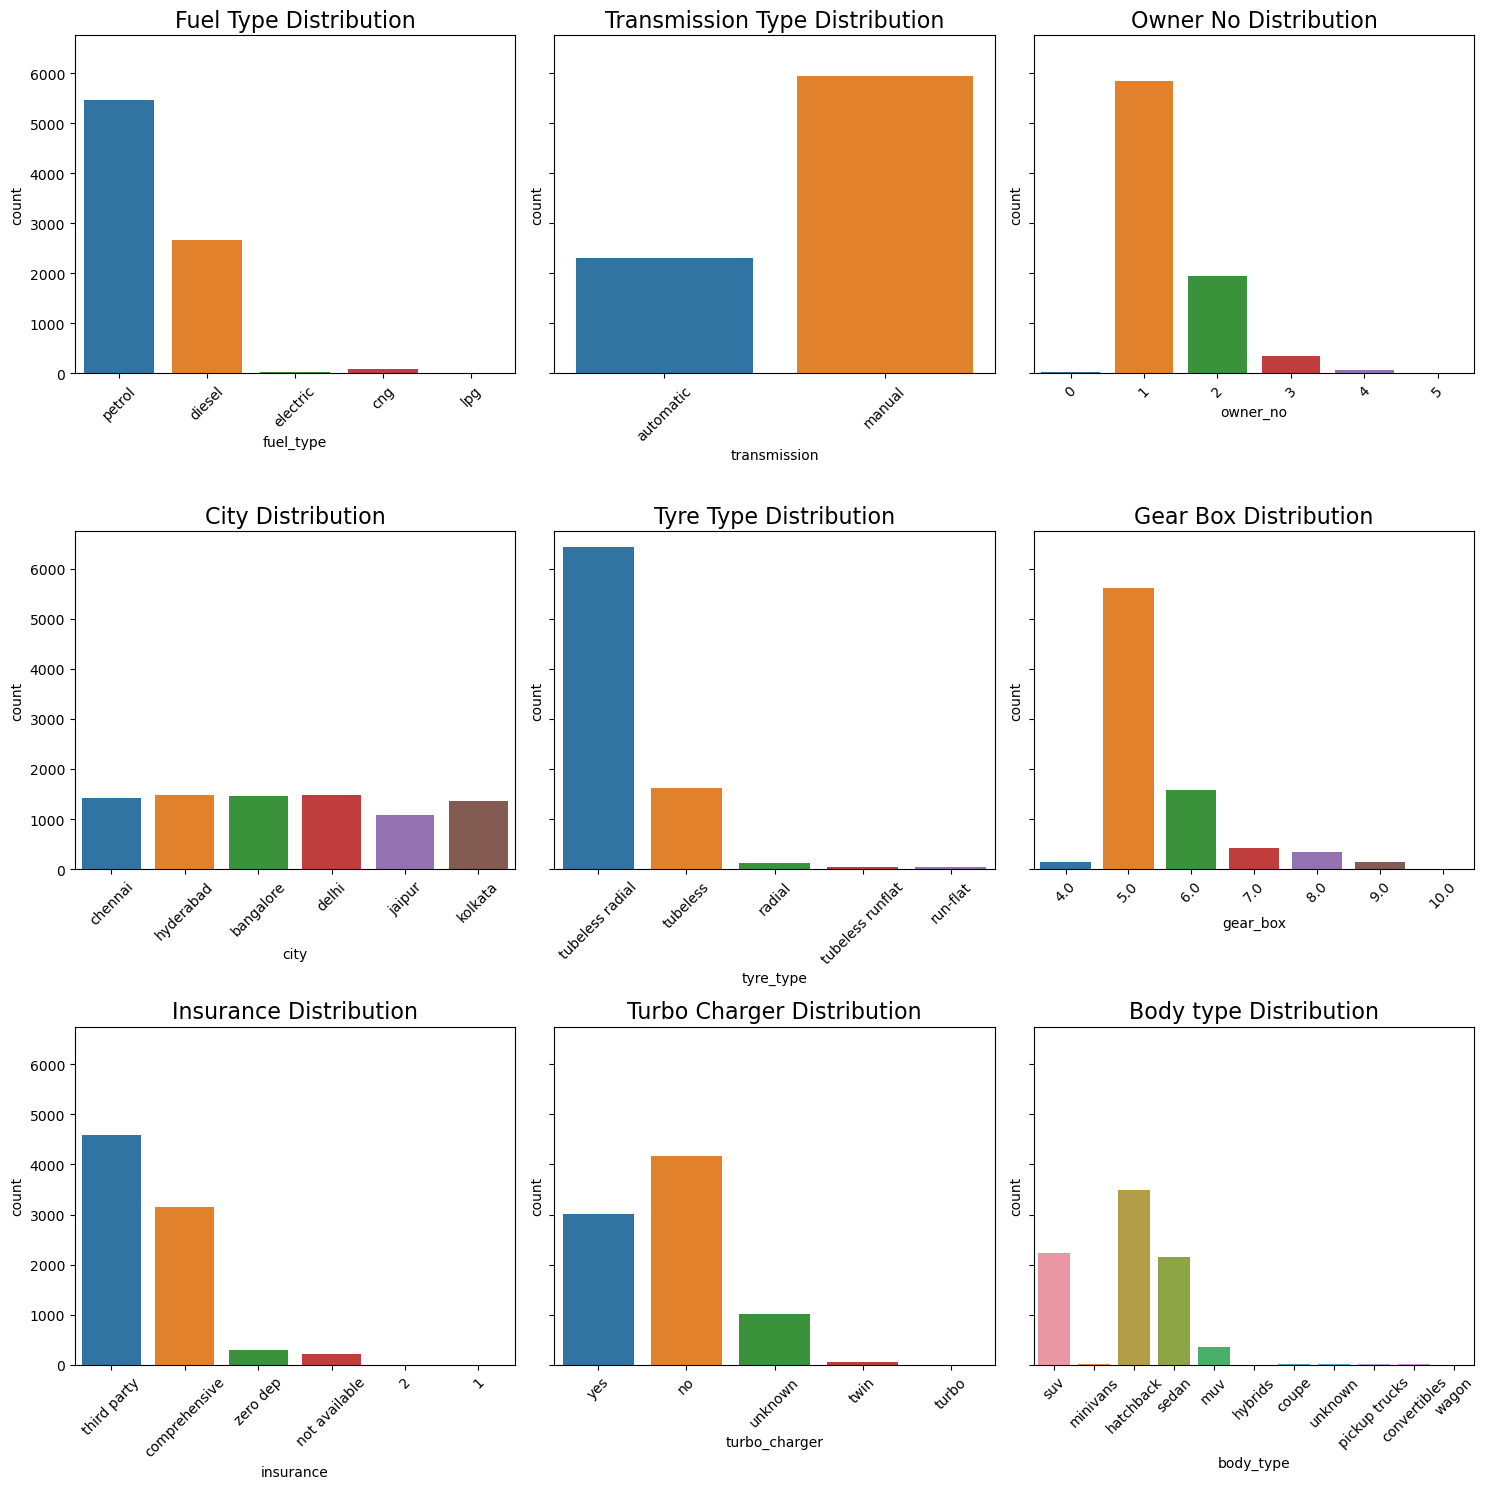

In [21]:
# List of column names and titles
columns = ['fuel_type', 'transmission', 'owner_no', 'city', 'tyre_type', 'gear_box', 'insurance',
           'turbo_charger','body_type']
titles = ['Fuel Type Distribution', 'Transmission Type Distribution', 'Owner No Distribution', 
          'City Distribution', 'Tyre Type Distribution', 'Gear Box Distribution', 
          'Insurance Distribution', 'Turbo Charger Distribution','Body type Distribution']

# Create subplots
fig, axes = plt.subplots(3, 3, figsize=(15, 15), sharey=True)

# Loop through the axes and plot
for i, ax in enumerate(axes.flat):
    sns.countplot(ax=ax, x=df[columns[i]])
    ax.set_title(titles[i], fontsize=16)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


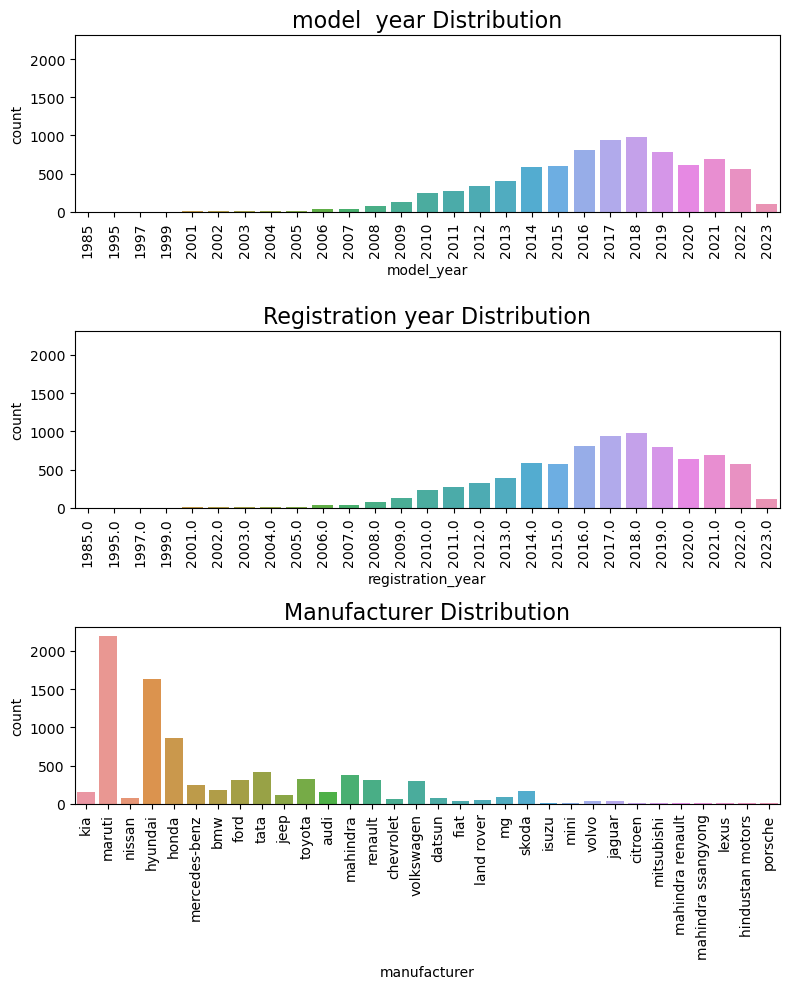

In [22]:
# List of column names and titles
columns = ['model_year','registration_year','manufacturer']
titles = ['model  year Distribution', 'Registration year Distribution', 'Manufacturer Distribution']


# Create subplots
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharey=True)
2
# Loop through the axes and plot
for i, ax in enumerate(axes.flat):
    sns.countplot(ax=ax, x=df[columns[i]])
    ax.set_title(titles[i], fontsize=16)
    ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


In [23]:
# model year and registration year are similar and show same trends so i'm dropping registration_year

df = df.drop(['registration_year'], axis=1)

In [24]:
# Identify numerical columns

numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
print(numerical_cols)

Index(['kilometers_driven', 'owner_no', 'model_year', 'price', 'engine',
       'max_power', 'torque', 'wheel_size', 'seats', 'no_of_cylinders',
       'values_per_cylinder', 'length', 'width', 'height', 'wheel_base',
       'kerb_weight', 'gear_box', 'alloy_wheel_size', 'no_of_doors',
       'cargo_volumn'],
      dtype='object')


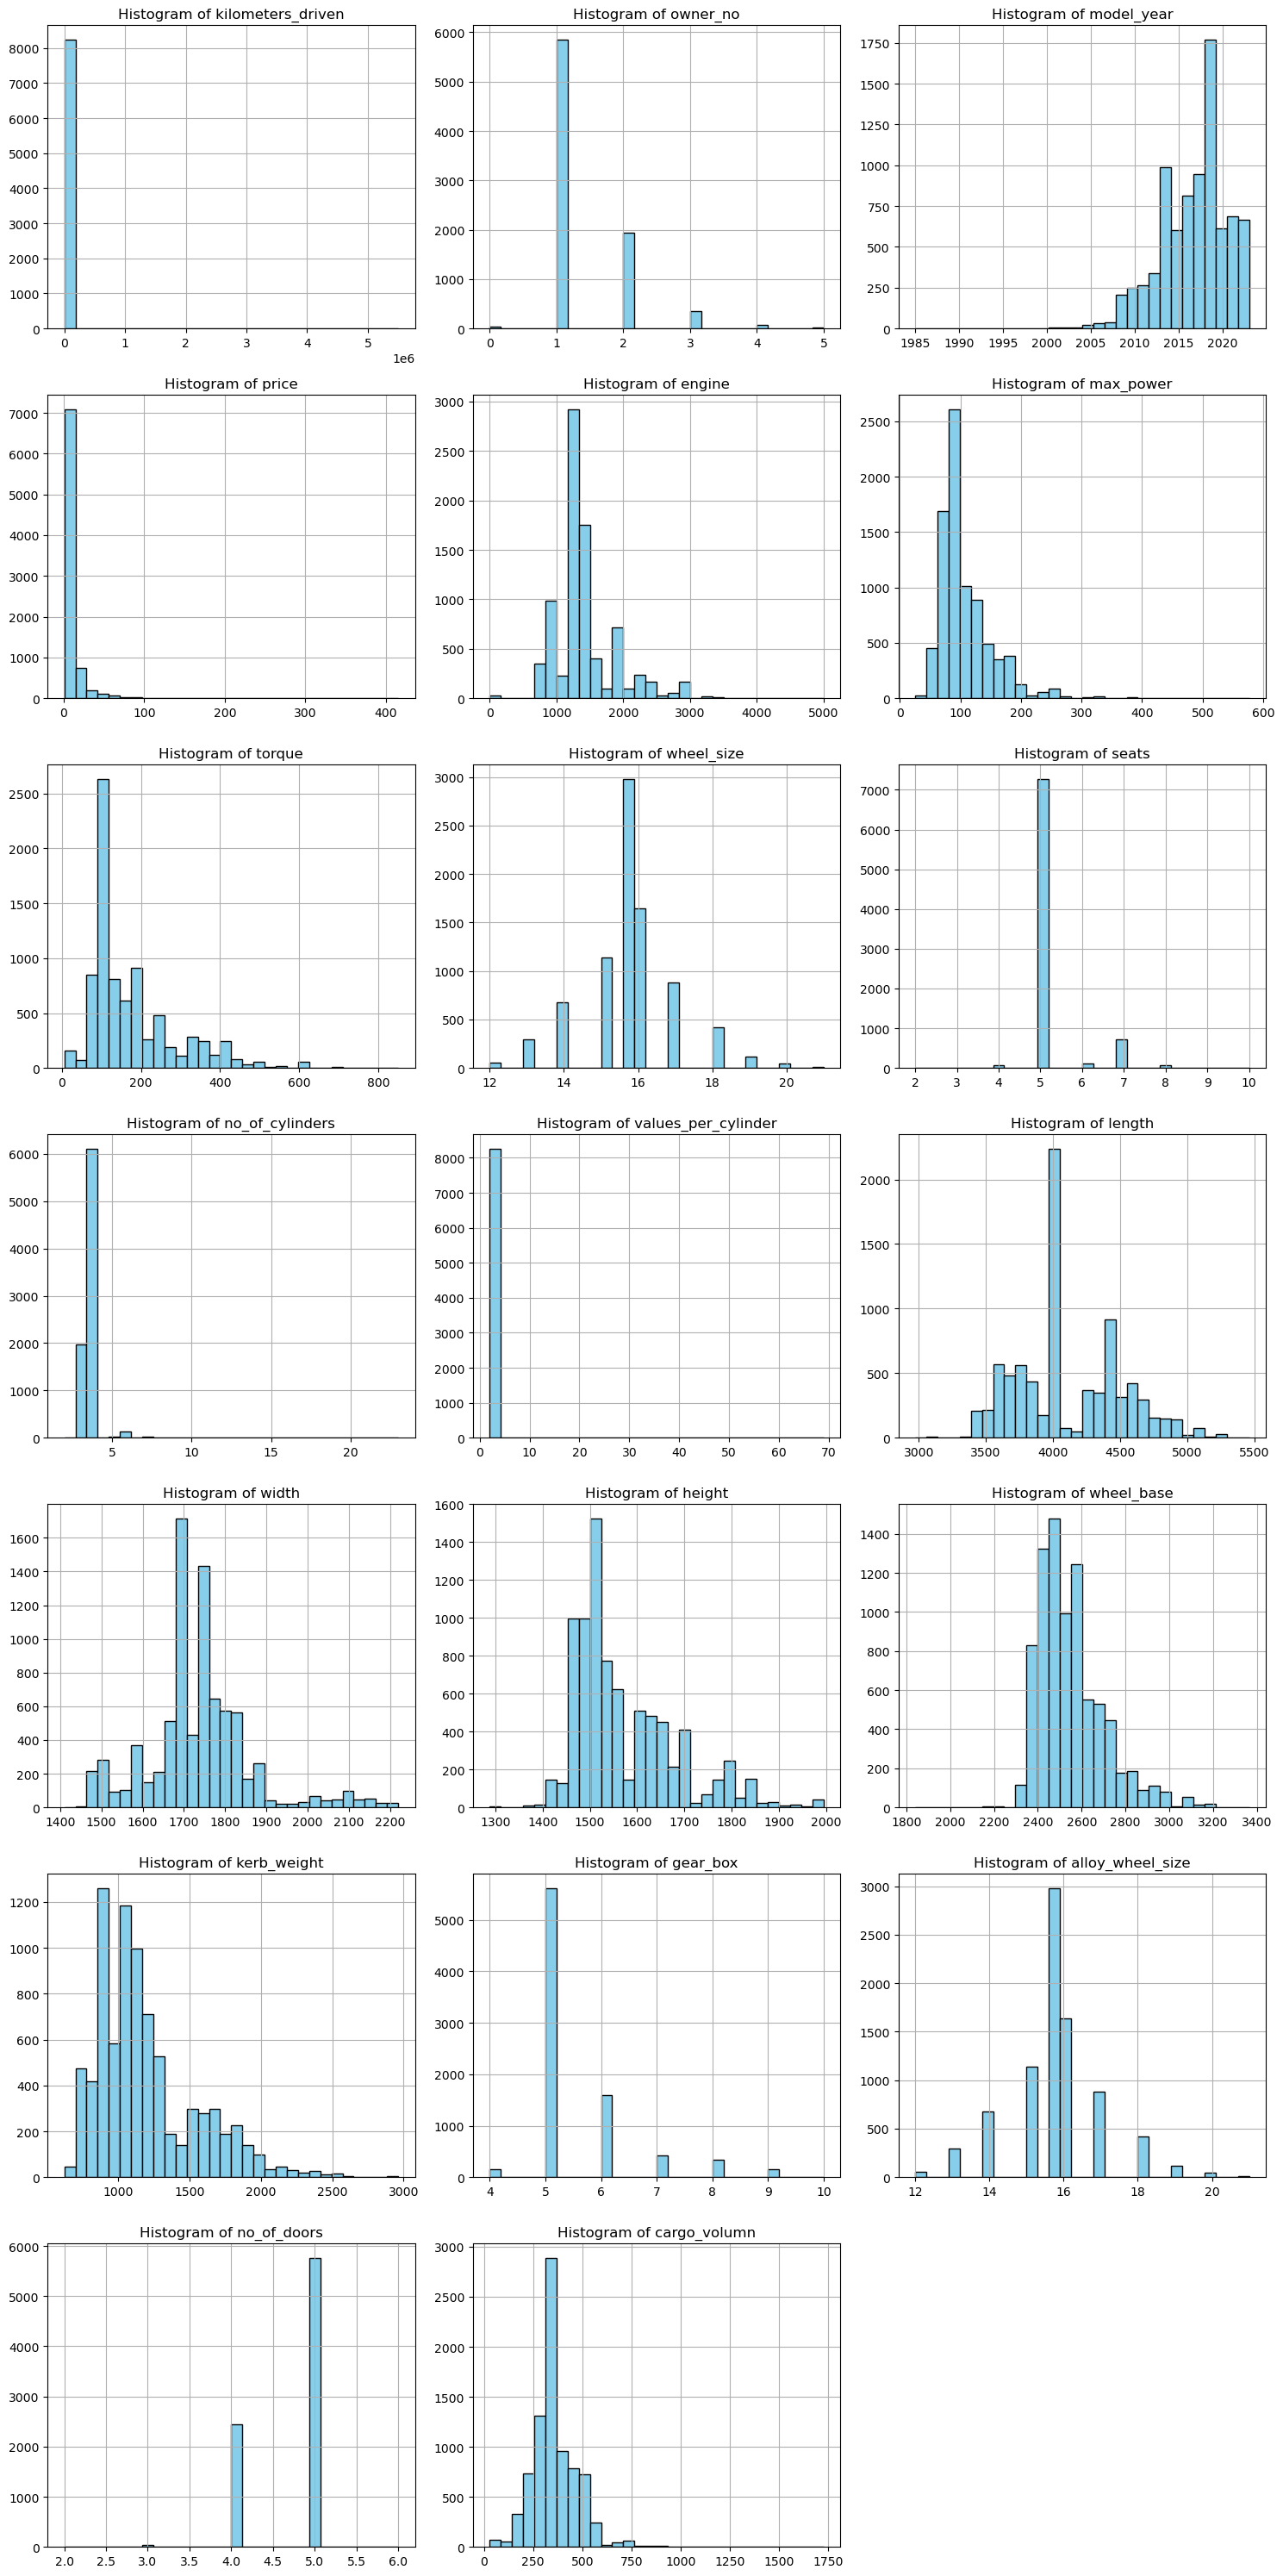

In [25]:
# Histograms for numerical columns

plt.figure(figsize=(15, 30))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(len(numerical_cols) // 3 + 1, 3, i)  # Adjusting for 3 columns
    df[col].hist(bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Histogram of {col}')
plt.tight_layout()
plt.show()



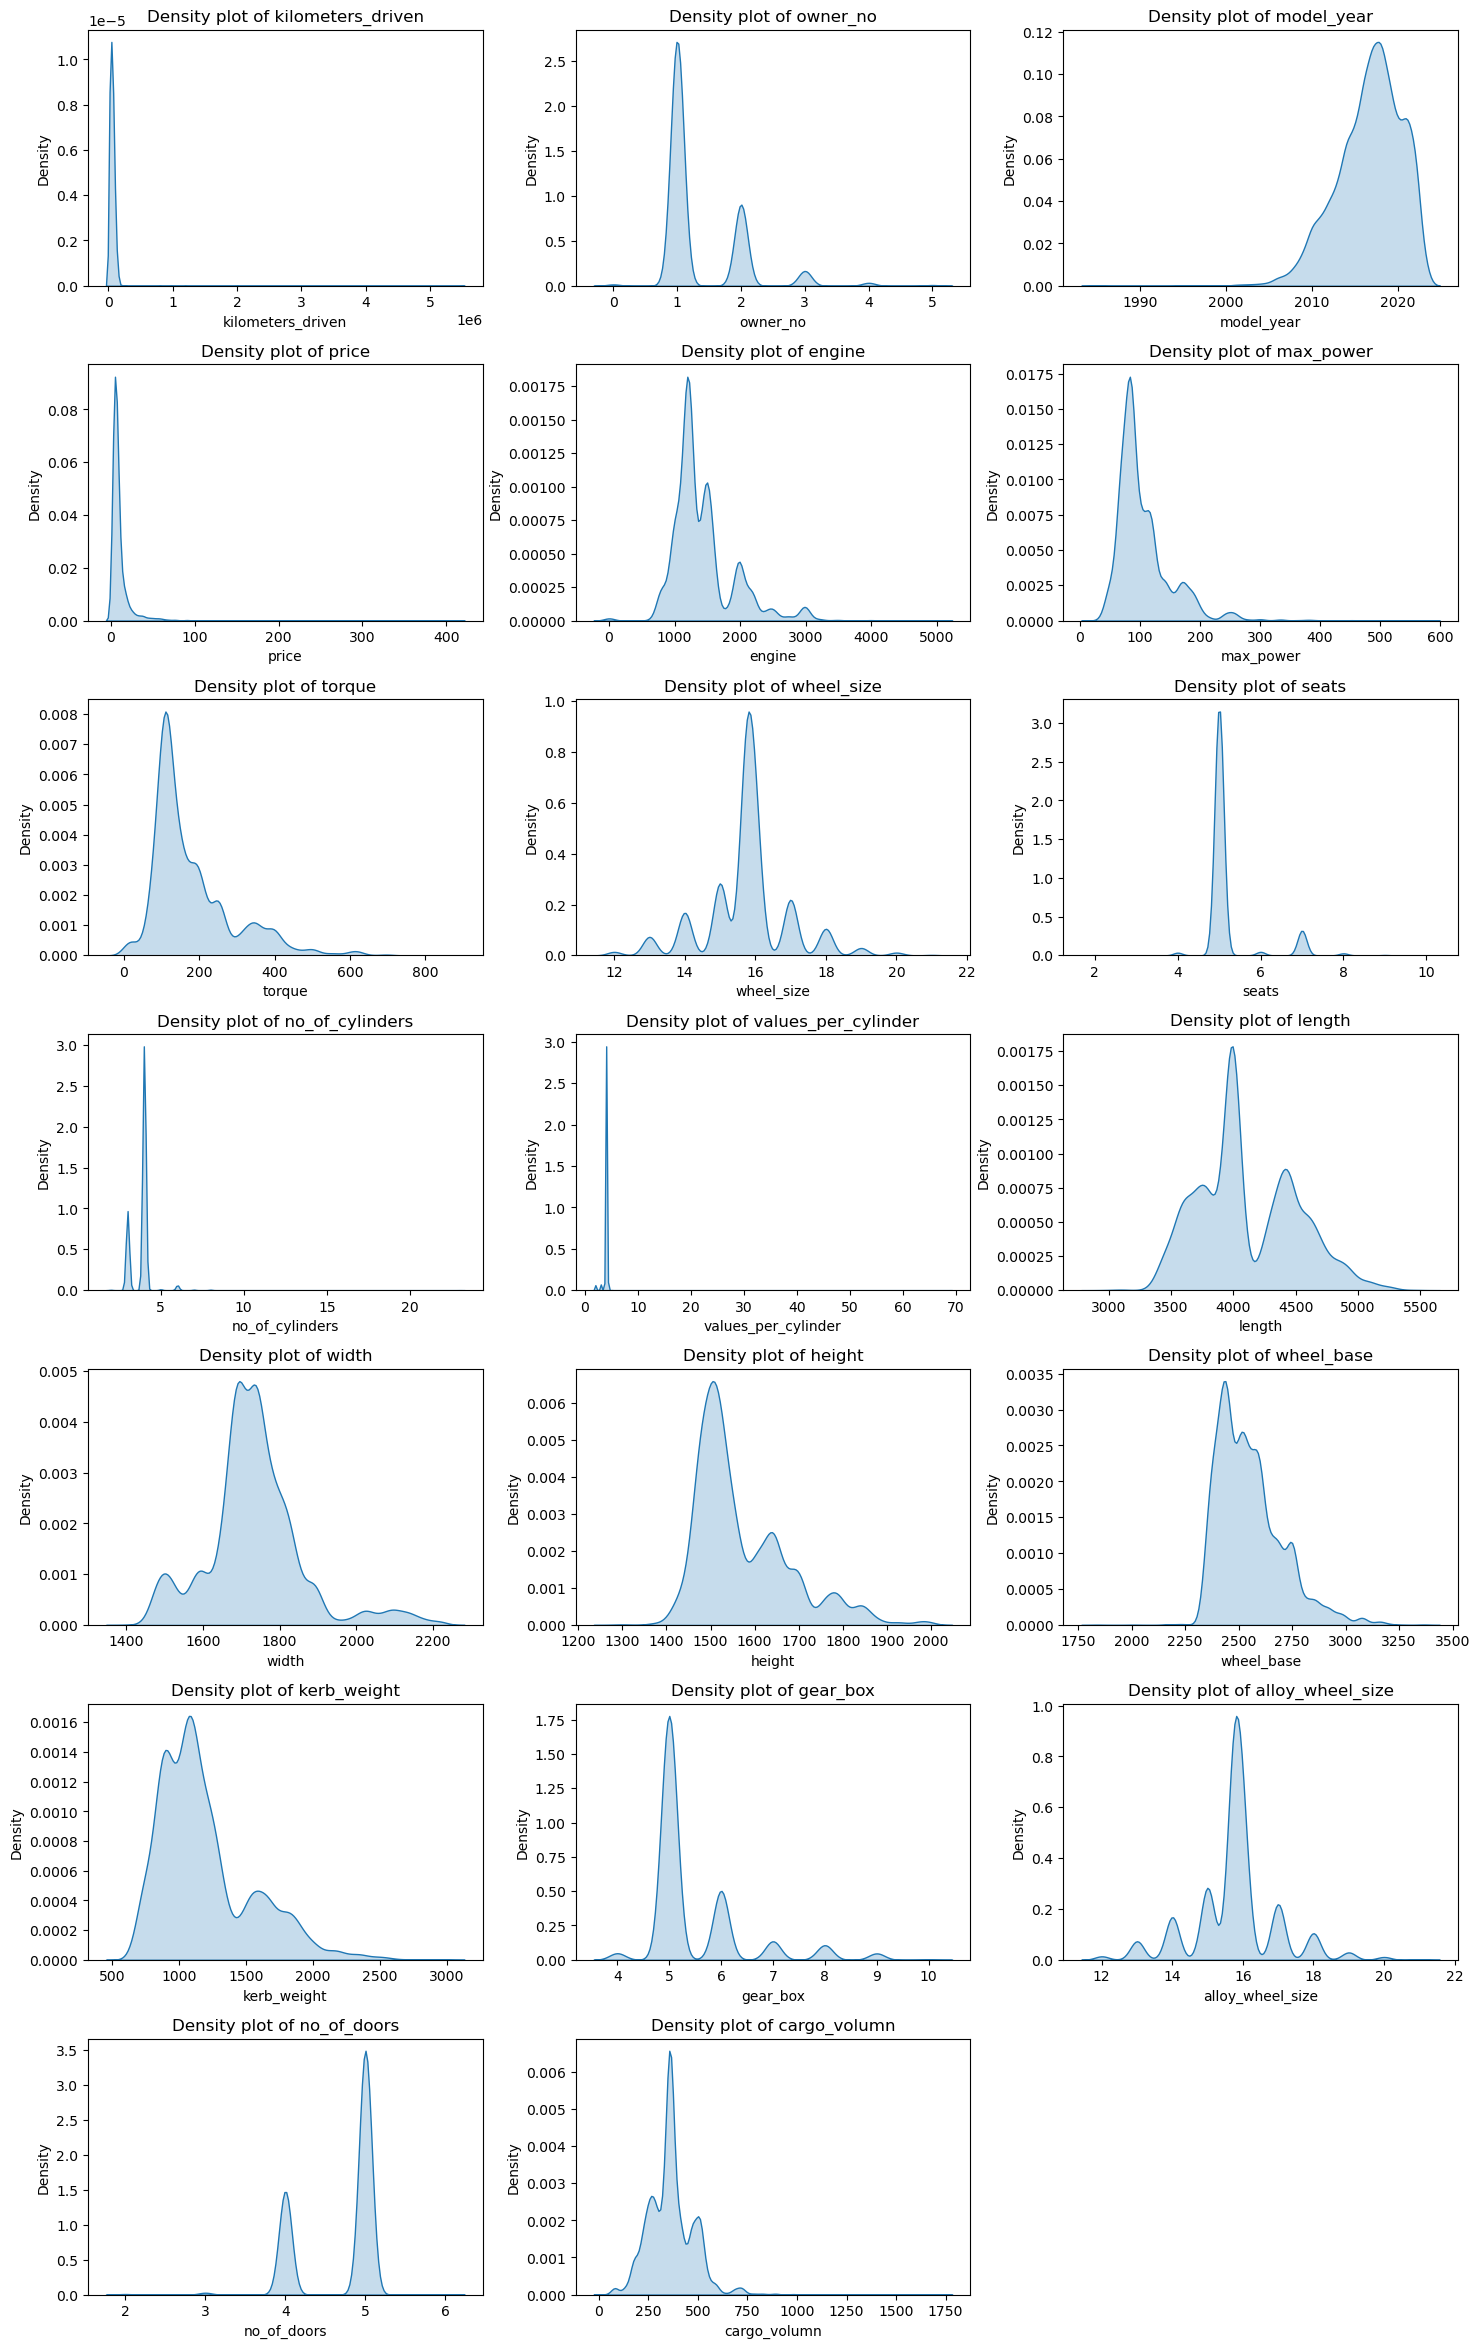

In [27]:
# kde plot for numerical columns

plt.figure(figsize=(15, 30))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(9, 3, i)
    sns.kdeplot(df[col], shade=True)
    plt.title(f'Density plot of {col}')
plt.tight_layout()
plt.show()

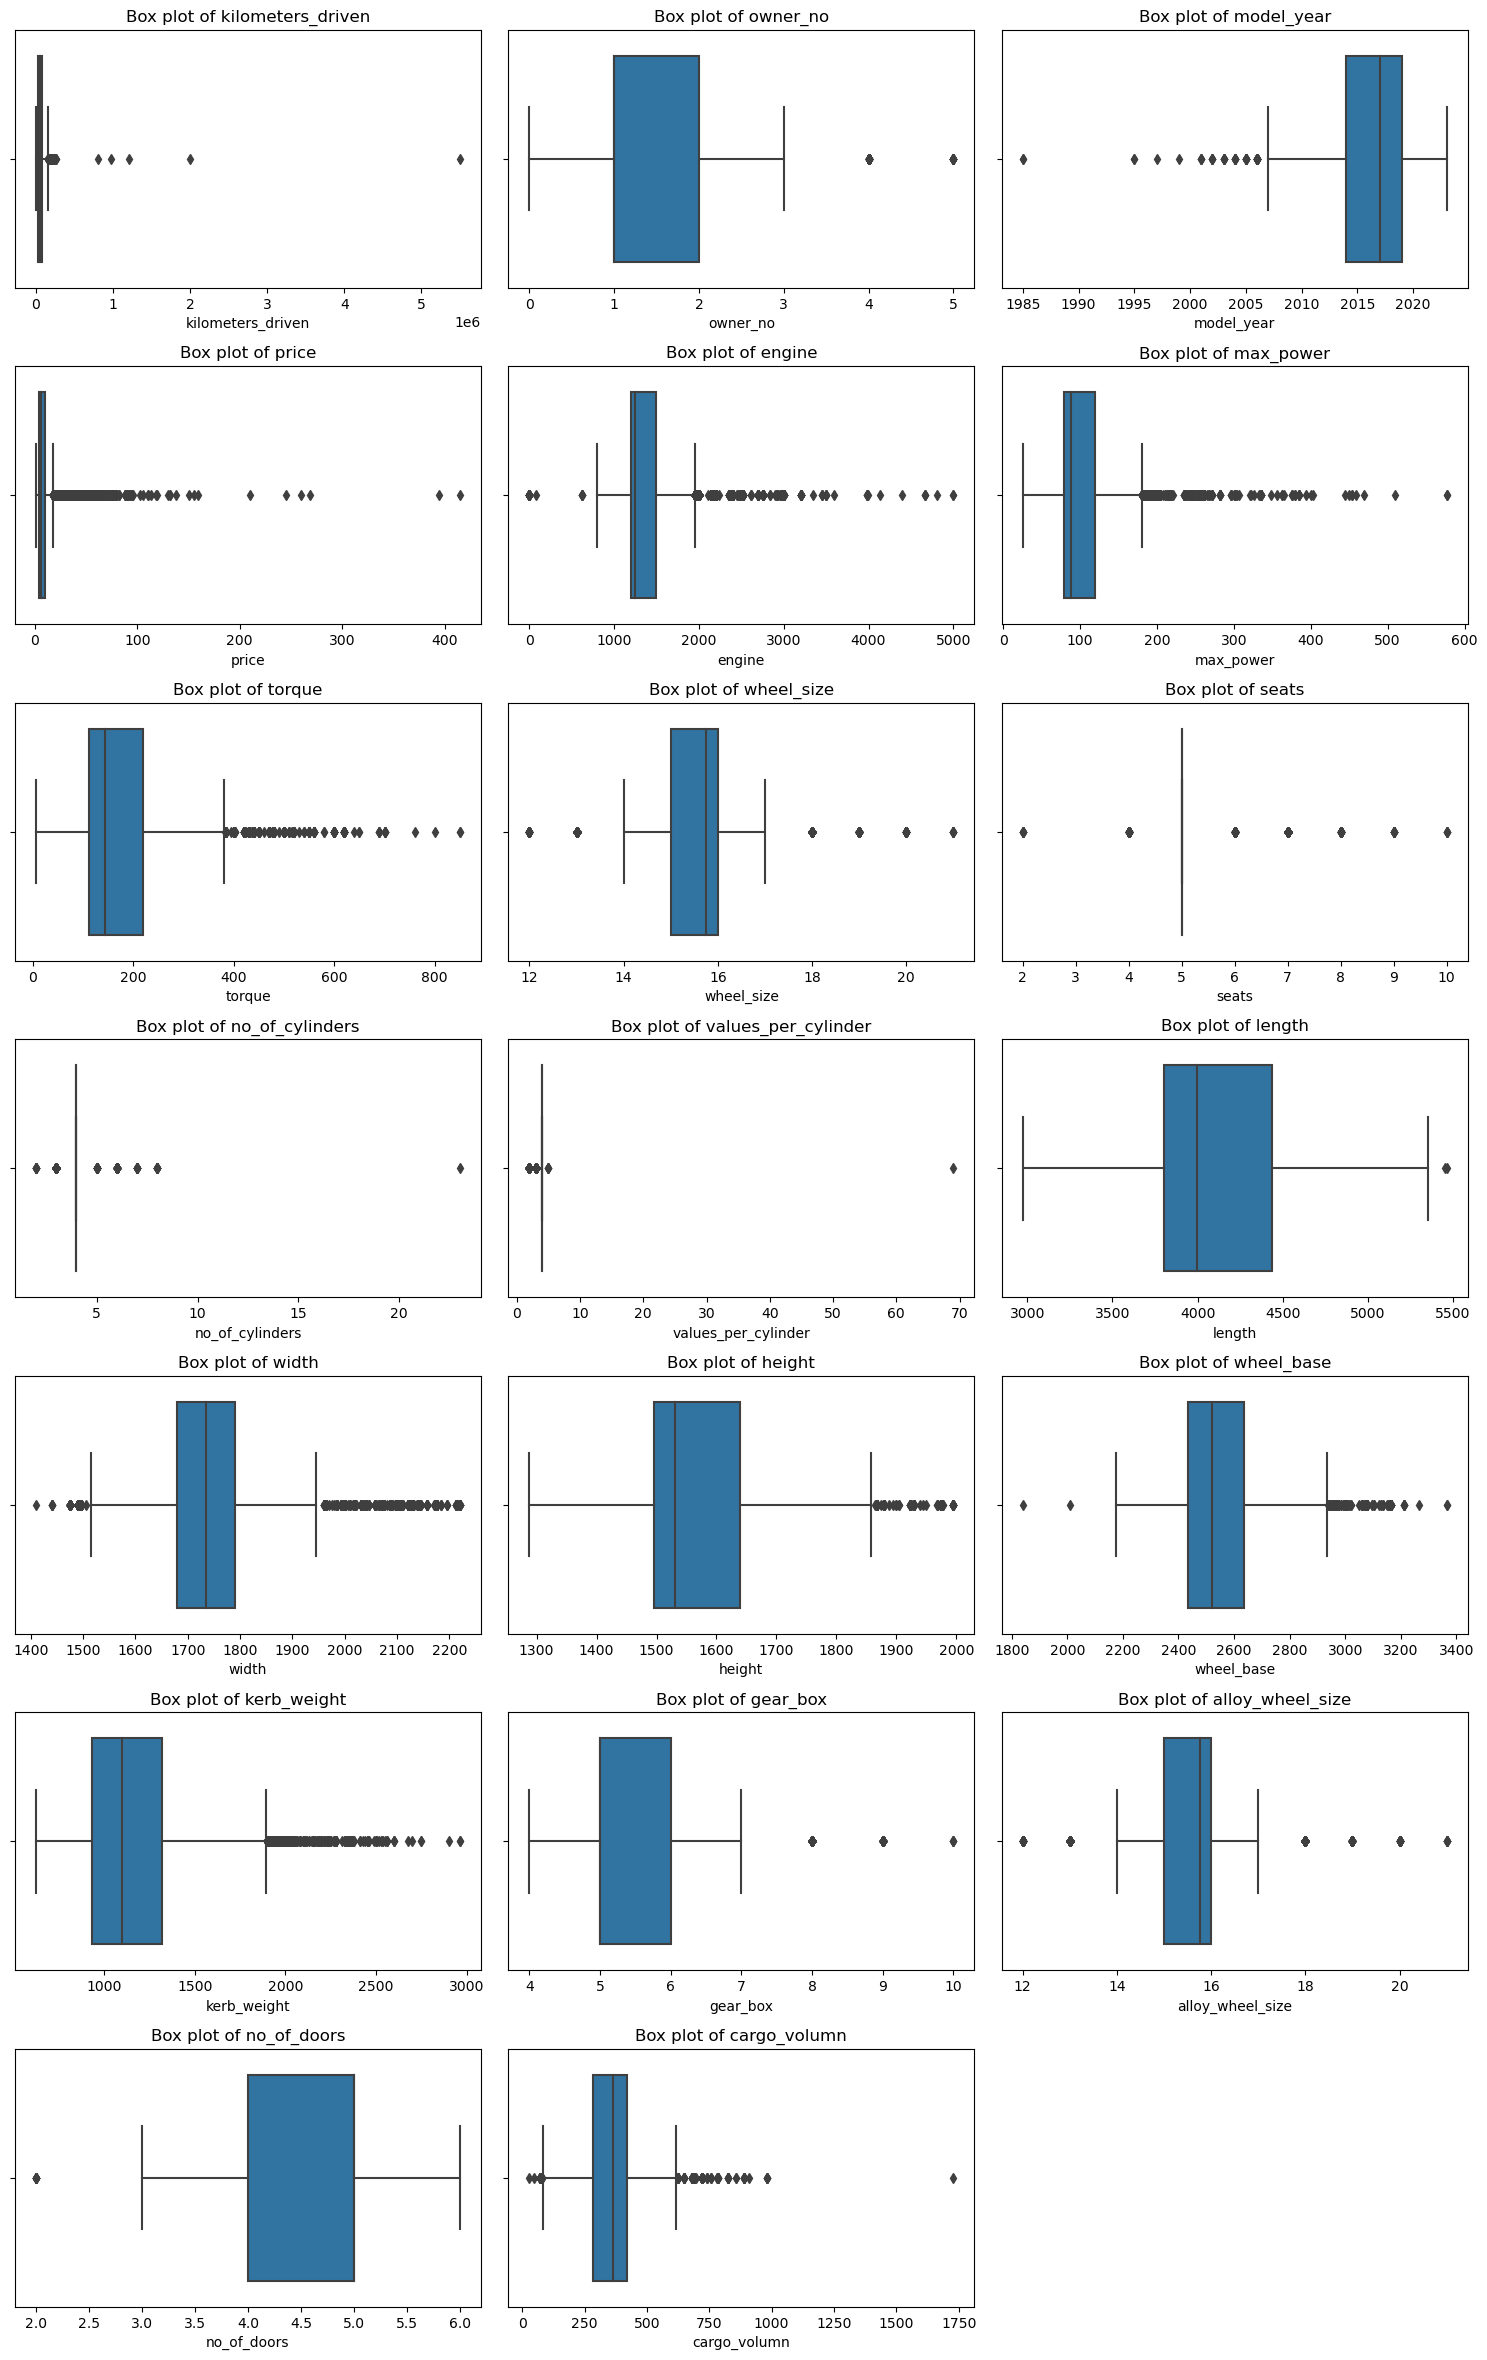

In [28]:
# box plots o analyze outliers

plt.figure(figsize=(15, 30))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(9, 3, i)
    sns.boxplot(x=df[col])  # Pass the column as keyword argument
    plt.title(f'Box plot of {col}')
plt.tight_layout()
plt.show()


In [29]:
numerical_cols.shape

(20,)

### correlation analysis

In [30]:
# Correlation of numerical features with 'price'
price_corr = df[numerical_cols].corr()['price'].sort_values(ascending=False)

# Display the correlations
print(price_corr)


price                  1.000000
max_power              0.747578
torque                 0.646549
gear_box               0.641060
kerb_weight            0.580328
wheel_base             0.572263
wheel_size             0.554778
alloy_wheel_size       0.554778
width                  0.549261
engine                 0.535208
length                 0.496106
no_of_cylinders        0.384720
model_year             0.293498
cargo_volumn           0.290717
height                 0.201793
seats                  0.081020
values_per_cylinder    0.030083
no_of_doors           -0.043203
kilometers_driven     -0.074958
owner_no              -0.113699
Name: price, dtype: float64


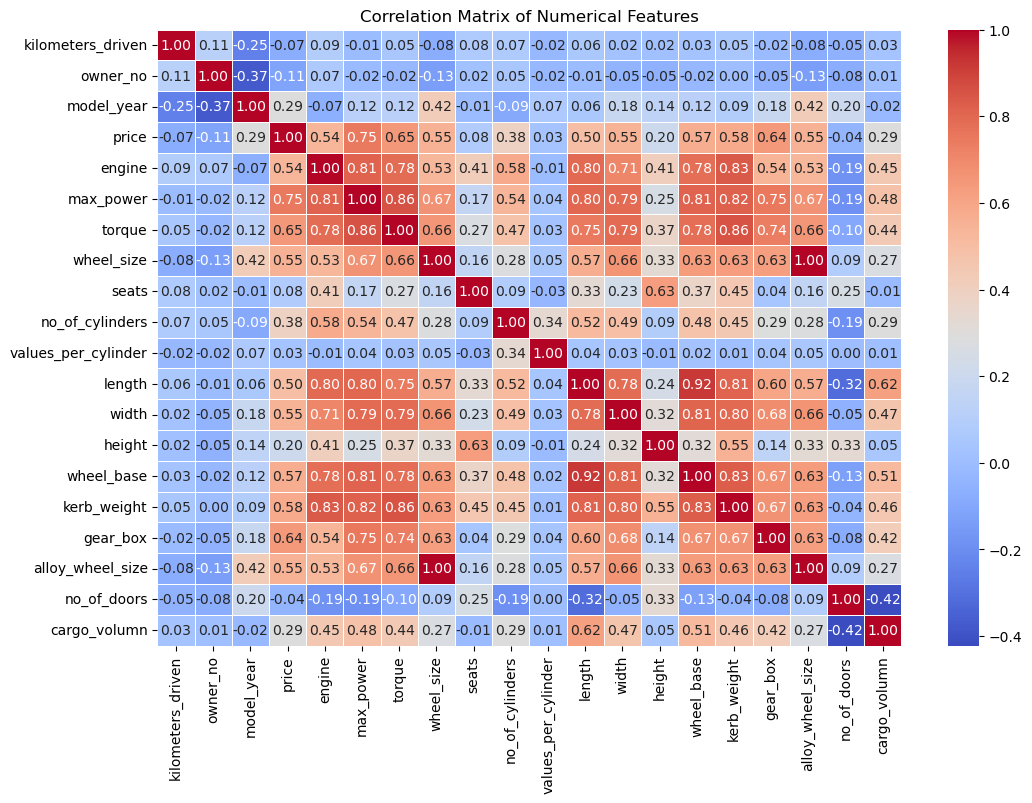

In [31]:
corr_matrix = df[numerical_cols].corr()

# Plot heatmap of correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

In [32]:
# dropping Features with a correlation lower than 0.2 with price

# wheel_size and alloy_wheel_size: Perfectly correlated, both at 0.554 with price. We can drop one, say alloy_wheel_size.

# width, length, kerb_weight, and wheel_base: These features are all highly correlated with each other. 
# Kerb weight, wheel base is highly corellateed with engine, max_power, torque 

# max_power and engine: Moderate correlation between each other, but both have meaningful correlations with price. It’s best to keep both.
# More features increase the dimensionality of the data, which can add computational cost and slow down model training.

In [33]:
# Columns to drop based on low correlation with price and redundancy with other features
columns_to_drop = [
    'seats', 'values_per_cylinder', 'no_of_doors', 
    'alloy_wheel_size', 'width', 'length', 'wheel_base','kerb_weight'
]

# Drop the columns
df = df.drop(columns=columns_to_drop)

# Display remaining columns
print("Remaining columns after dropping:", df.columns)


Remaining columns after dropping: Index(['fuel_type', 'body_type', 'kilometers_driven', 'transmission',
       'owner_no', 'manufacturer', 'model_year', 'price', 'insurance',
       'engine', 'max_power', 'torque', 'wheel_size', 'no_of_cylinders',
       'turbo_charger', 'height', 'gear_box', 'tyre_type', 'cargo_volumn',
       'city'],
      dtype='object')


## Normalizing Numerical Features

In [34]:
# Using min max scaler as the data is not normally distributed

# Identify numerical columns, excluding the target variable 'price'
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.drop('price')

# Initialize the scaler
scaler = MinMaxScaler()

# Scale only the selected numerical columns
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [35]:
df.head()

,fuel_type,body_type,kilometers_driven,transmission,owner_no,manufacturer,model_year,price,insurance,engine,max_power,torque,wheel_size,no_of_cylinders,turbo_charger,height,gear_box,tyre_type,cargo_volumn,city
0,petrol,suv,0.003636,automatic,0.2,kia,0.973684,11.50,third party,0.1996,0.168641,0.196587,0.444444,0.047619,yes,0.500707,0.500000,tubeless radial,0.213655,chennai
1,petrol,minivans,0.003761,manual,0.2,maruti,0.789474,4.15,comprehensive,0.2392,0.086352,0.112454,0.416888,0.095238,no,0.724187,0.166667,tubeless,0.300765,chennai
2,petrol,suv,0.005455,manual,0.2,nissan,0.947368,7.50,third party,0.1998,0.132848,0.182368,0.444444,0.047619,yes,0.401697,0.166667,tubeless radial,0.180695,chennai
3,petrol,hatchback,0.010772,manual,0.2,hyundai,0.789474,3.98,comprehensive,0.2172,0.077372,0.110132,0.416888,0.095238,no,0.370580,0.166667,tubeless,0.115362,chennai
4,petrol,hatchback,0.009091,manual,0.2,honda,0.789474,5.50,third party,0.2398,0.114834,0.123119,0.333333,0.095238,no,0.362093,0.166667,tubeless radial,0.191289,chennai


# Encoding the data 

In [37]:
# Apply One-Hot Encoding to nominal categorical variables

categorical_cols = df.select_dtypes(include=['object']).columns

#data_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
for col in df.columns :
    print(col)

fuel_type
body_type
kilometers_driven
transmission
owner_no
manufacturer
model_year
price
insurance
engine
max_power
torque
wheel_size
no_of_cylinders
turbo_charger
height
gear_box
tyre_type
cargo_volumn
city


In [41]:
data_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
data_encoded.head()

,kilometers_driven,owner_no,model_year,price,engine,max_power,torque,wheel_size,no_of_cylinders,height,gear_box,cargo_volumn,fuel_type_diesel,fuel_type_electric,fuel_type_lpg,fuel_type_petrol,body_type_coupe,body_type_hatchback,body_type_hybrids,body_type_minivans,body_type_muv,body_type_pickup trucks,body_type_sedan,body_type_suv,body_type_unknown,body_type_wagon,transmission_manual,manufacturer_bmw,manufacturer_chevrolet,manufacturer_citroen,manufacturer_datsun,manufacturer_fiat,manufacturer_ford,manufacturer_hindustan motors,manufacturer_honda,manufacturer_hyundai,manufacturer_isuzu,manufacturer_jaguar,manufacturer_jeep,manufacturer_kia,manufacturer_land rover,manufacturer_lexus,manufacturer_mahindra,manufacturer_mahindra renault,manufacturer_mahindra ssangyong,manufacturer_maruti,manufacturer_mercedes-benz,manufacturer_mg,manufacturer_mini,manufacturer_mitsubishi,manufacturer_nissan,manufacturer_porsche,manufacturer_renault,manufacturer_skoda,manufacturer_tata,manufacturer_toyota,manufacturer_volkswagen,manufacturer_volvo,insurance_2,insurance_comprehensive,insurance_not available,insurance_third party,insurance_zero dep,turbo_charger_turbo,turbo_charger_twin,turbo_charger_unknown,turbo_charger_yes,tyre_type_run-flat,tyre_type_tubeless,tyre_type_tubeless radial,tyre_type_tubeless runflat,city_chennai,city_delhi,city_hyderabad,city_jaipur,city_kolkata
0,0.003636,0.2,0.973684,11.50,0.1996,0.168641,0.196587,0.444444,0.047619,0.500707,0.500000,0.213655,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0
1,0.003761,0.2,0.789474,4.15,0.2392,0.086352,0.112454,0.416888,0.095238,0.724187,0.166667,0.300765,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0
2,0.005455,0.2,0.947368,7.50,0.1998,0.132848,0.182368,0.444444,0.047619,0.401697,0.166667,0.180695,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,0,1,0,0,0,0
3,0.010772,0.2,0.789474,3.98,0.2172,0.077372,0.110132,0.416888,0.095238,0.370580,0.166667,0.115362,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0
4,0.009091,0.2,0.789474,5.50,0.2398,0.114834,0.123119,0.333333,0.095238,0.362093,0.166667,0.191289,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0


In [42]:
pd.set_option('display.max_rows', None)
data_encoded.isna().sum()

kilometers_driven                  0
owner_no                           0
model_year                         0
price                              0
engine                             0
max_power                          0
torque                             0
wheel_size                         0
no_of_cylinders                    0
height                             0
gear_box                           0
cargo_volumn                       0
fuel_type_diesel                   0
fuel_type_electric                 0
fuel_type_lpg                      0
fuel_type_petrol                   0
body_type_coupe                    0
body_type_hatchback                0
body_type_hybrids                  0
body_type_minivans                 0
body_type_muv                      0
body_type_pickup trucks            0
body_type_sedan                    0
body_type_suv                      0
body_type_unknown                  0
body_type_wagon                    0
transmission_manual                0
m

In [43]:
data_encoded.shape

(8259, 76)

# Price Predction Model Development

In [44]:
#importing required librarief for price prediction

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

In [45]:
# defining target and features

X = data_encoded.drop(columns=['price'])  # Assuming 'price' is the target variable
y = data_encoded['price']

In [46]:
# Splitting into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (6607, 75)
Testing set shape: (1652, 75)


In [47]:
# Initializing  models

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}


In [48]:
# Dictionary to store performance metrics
performance_metrics = {}

for model_name, model in models.items():
    # Training the model
    model.fit(X_train, y_train)
    
    # Making predictions on the test set
    y_pred = model.predict(X_test)
    
    # Calculate performance metrics
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    # Storing metrics
    performance_metrics[model_name] = {
        "MAE": mae,
        "MSE": mse,
        "R-squared": r2
    }

# Converting metrics to a DataFrame for easier comparison
performance_df = pd.DataFrame(performance_metrics).T
print("Model Performance Comparison:")
print(performance_df)


Model Performance Comparison:
                        MAE        MSE  R-squared
Linear Regression  3.645338  37.125214   0.731426
Decision Tree      1.547992  20.278690   0.853298
Random Forest      1.227437  13.120999   0.905079
Gradient Boosting  1.593564  16.627009   0.879716


###  Random Forest has the best overall performance with the lowest MAE and MSE and the highest R-squared.

# Finetuing the Model

### Grid search CV

In [49]:
# Parameter grid for GridSearchCV
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# GridSearchCV for Random Forest
grid_search_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs = -1,
    verbose = 2
)
grid_search_rf.fit(X_train, y_train)

# Best parameters and evaluation from GridSearchCV
best_params_grid = grid_search_rf.best_params_
best_model_grid = grid_search_rf.best_estimator_

# Evaluate the GridSearchCV-tuned model
y_pred_grid = best_model_grid.predict(X_test)
final_mae_grid = mean_absolute_error(y_test, y_pred_grid)
final_mse_grid = mean_squared_error(y_test, y_pred_grid)
final_r2_grid = r2_score(y_test, y_pred_grid)

print("GridSearchCV - Best Parameters:", best_params_grid)
print("GridSearchCV - Model Performance:")
print("MAE:", final_mae_grid)
print("MSE:", final_mse_grid)
print("R-squared:", final_r2_grid)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
GridSearchCV - Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
GridSearchCV - Model Performance:
MAE: 1.2324638402072847
MSE: 13.42809633146801
R-squared: 0.9028575349758434


### Grid Search has yielded a significantly improved model! The new R² score of 0.9028 
### Indicating that this model explains about 90.28% of the variance in car prices. 
### The Mean Absolute Error (MAE) and Mean Squared Error (MSE) have also decreased

# Saving the tuned model

In [50]:
import pickle

In [51]:
# Saving the model
with open("car_price_model3.pkl", "wb") as model_file:
    pickle.dump(best_model_grid, model_file)

In [52]:
# Saving the scaler
with open("scaler3.pkl", "wb") as scaler_file:
    pickle.dump(scaler, scaler_file)

In [53]:
import sklearn
print(sklearn.__version__)


1.5.2
